## Phase 5: Predict for a New Applicant

Run the cell below to load the data, load the trained model, predict one new applicant, and explain the prediction with SHAP.

Background dataset has 491 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=491 when initializing the masker.


Prediction: Approved
Approval probability: 79.80%


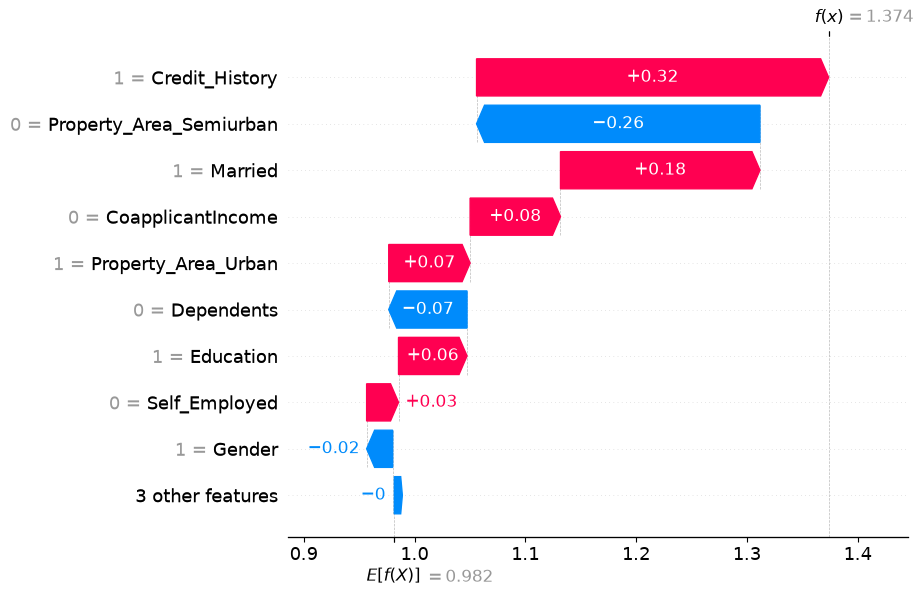

(np.int64(1), np.float64(0.7979858741275604))

In [10]:
from pathlib import Path

import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split

%matplotlib inline

current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir

data_path = project_root / 'data' / 'cleaned_train.csv'
model_path = project_root / 'models' / 'logistic_regression_model.pkl'

df = pd.read_csv(data_path)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = joblib.load(model_path)
explainer = shap.LinearExplainer(model, X_train)


def predict_new_applicant(applicant_dict):
    new_df = pd.DataFrame([applicant_dict])

    missing_cols = set(X_train.columns) - set(new_df.columns)
    extra_cols = set(new_df.columns) - set(X_train.columns)

    if missing_cols:
        raise ValueError(f'Missing required columns: {sorted(missing_cols)}')
    if extra_cols:
        raise ValueError(f'Unexpected columns: {sorted(extra_cols)}')

    new_df = new_df[X_train.columns]

    prediction = model.predict(new_df)[0]
    probability = model.predict_proba(new_df)[0][1]

    print('Prediction:', 'Approved' if prediction == 1 else 'Rejected')
    print(f'Approval probability: {probability:.2%}')

    shap_val = explainer(new_df)
    shap.plots.waterfall(shap_val[0])

    return prediction, probability


new_applicant = {
    'Gender': 1,                 # 1 = Male, 0 = Female
    'Married': 1,                # 1 = Yes, 0 = No
    'Dependents': 0,
    'Education': 1,              # 1 = Graduate, 0 = Not Graduate
    'Self_Employed': 0,          # 1 = Yes, 0 = No
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 0,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,         # 1 = has credit history, 0 = does not
    'Property_Area_Semiurban': 0,
    'Property_Area_Urban': 1
}

predict_new_applicant(new_applicant)